# Sentiment Analysis using NLP Pipeline & ML Models

# import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2. Download NLTK Stopwords

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Amrutha
[nltk_data]     Reddy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 🔹 3. Load Dataset

In [5]:
data = pd.read_csv("train.csv")

# Display Dataset

In [6]:
data.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


# dataset info

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


# check null values

In [8]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

# chexk sentiment distribution

In [9]:
data['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

# 8. Visualize Sentiment Distribution

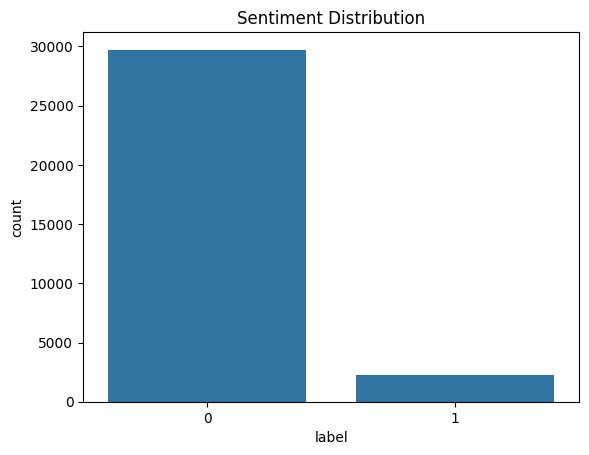

In [10]:
sns.countplot(x=data['label'])
plt.title("Sentiment Distribution")
plt.show()

# 9. Create Text Cleaning Function

In [11]:
stemmer = PorterStemmer()

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

# Clean Tweets

In [12]:
data['cleaned_text'] = data['tweet'].apply(clean_text)

In [13]:
data[['tweet', 'cleaned_text']].head()

,tweet,cleaned_text
0,@user when a father is dysfunctional and is s...,user father dysfunct selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,user user thank lyft credit use caus offer whe...
2,bihday your majesty,bihday majesti
3,#model i love u take with u all the time in ...,model love u take u time ur
4,factsguide: society now #motivation,factsguid societi motiv


# Features and Labels

In [15]:
X = data['cleaned_text']

y = data['label']

# TF-IDF Vectorization

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

# Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression Model

In [18]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Predict Using Logistic Regression 

In [20]:
lr_pred = lr_model.predict(X_test)

# Accuracy Score

In [21]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9504145158767402


# Classification Report

In [22]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.90      0.34      0.50       456

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.73      6393
weighted avg       0.95      0.95      0.94      6393



# 19. Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[5920   17]
 [ 300  156]]


# Plot Confusion Matrix`

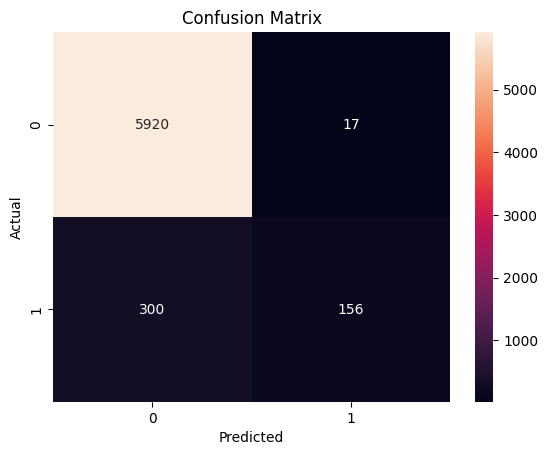

In [24]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Train Naive Bayes Model

In [25]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


# . Predict Using Naive Bayes

In [27]:
nb_pred = nb_model.predict(X_test)

# Naive Bayes Accuracy

In [28]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9502580947911778


# Compare Models

In [29]:
print("Logistic Regression:", lr_accuracy)

print("Naive Bayes:", nb_accuracy)

Logistic Regression: 0.9504145158767402
Naive Bayes: 0.9502580947911778


# Custom Prediction Function

In [30]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vector = vectorizer.transform([cleaned])

    prediction = lr_model.predict(vector)

    if prediction[0] == 1:
        return "Positive Sentiment"
    else:
        return "Negative Sentiment"

# Test Custom Reviews

In [32]:
print(predict_sentiment("I hate this movie"))

print(predict_sentiment("This is the worst product"))

Negative Sentiment
Negative Sentiment


# Conclusion

This project successfully implemented Sentiment Analysis using NLP preprocessing techniques and Machine Learning models. The workflow included text cleaning, stopword removal, stemming, TF-IDF vectorization, model training, and evaluation. Logistic Regression and Naive Bayes models were trained and compared for sentiment classification.
